<div>
    <img src="https://storage.googleapis.com/kaggle-datasets-images/1111/2005/082b5df90c0f8990d3beb9b68e394659/dataset-cover.jpg" />
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix 
from sklearn.decomposition import PCA

from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import plot_roc_curve

import warnings
warnings.filterwarnings('ignore')

<h1 id="dataset" style="color:#a9dee2; background:#004449; border:0.5px dotted;"> 
    <center>Dataset
        <a class="anchor-link" href="#datasets" target="_self">¶</a>
    </center>
</h1>

In [2]:
path = '/kaggle/input/ckdisease/kidney_disease.csv'
df = pd.read_csv(path)
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


## Cleaning & Encoding

In [3]:
df.rename(columns={'classification':'class'},inplace=True)
df['class']=df['class'].replace(to_replace={'ckd':1.0,'ckd\t':1.0,'notckd':0.0,'no':0.0})
df.drop('id',axis=1,inplace=True)

In [4]:
for i in ['rc','wc','pcv']:
    df[i] = df[i].str.extract('(\d+)').astype(float)
    
for i in ['age','bp','sg','al','su','bgr','bu','sc','sod','pot','hemo','rc','wc','pcv']:
    df[i].fillna(df[i].mean(),inplace=True)
    
df = df.dropna(axis=1)

## Split Training/Testing Data

In [5]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

X_train, X_test, y_train, y_test = train_test_split(
                                        X, y, test_size=0.33, random_state=42)

<h1 id="models" style="color:#a9dee2; background:#004449; border:0.5px dotted;"> 
    <center>Models
        <a class="anchor-link" href="#models" target="_self">¶</a>
    </center>
</h1>

In [6]:
model = {}
model['svm'] = {'model' : svm.SVC(gamma='auto'), 
                'params':{'clf__C':[1,10,20],'clf__kernel':['rbf','linear']}}

model['random_forest'] = {'model':RandomForestClassifier(),
                          'params':{ 'clf__n_estimators':[1,5,10]}}

logistic_regression = LogisticRegression(solver='liblinear', multi_class='auto')
model['logistic_regression'] = {'model': logistic_regression,
                                'params':{'clf__C':[1,5,10]}}

model['decision_tree'] = {'model': DecisionTreeClassifier(criterion='entropy'),
                          'params':{ 'clf__min_samples_split' : [4,5,6,7,8,9,10]}}

model['knn'] = {'model': KNeighborsClassifier( metric='minkowski',p=2 ),
                'params':{'clf__n_neighbors' :list(range(1,31)),'clf__weights' : ["uniform", "distance"]}}

model['naive_bayes'] = {'model': GaussianNB(),
                        'params':{'clf__var_smoothing': np.logspace(0,-9, num=100)}}

<h1 id="training" style="color:#a9dee2; background:#004449; border:0.5px dotted;"> 
    <center>Training
        <a class="anchor-link" href="#training" target="_self">¶</a>
    </center>
</h1>

In [7]:
models = {}

for k in list(model.keys()):
    
    model[k]['params']['pca__n_components'] =  [5, 15, 30, 45, 64]
    
    pipeline = Pipeline([
        ('standard', StandardScaler()),
        ('pca', PCA()),
        ('clf', model[k]['model']),
    ])

    parameters = [
        model[k]['params']
    ]

    clf = GridSearchCV(pipeline, parameters, cv=5, n_jobs=12, return_train_score=False, verbose=3)
    clf.fit(X_train, y_train)
    models[k] = {
        'model': clf,
        'best_score':clf.best_score_,
        'best_params':clf.best_params_
    }

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Fitting 5 folds for each of 500 candidates, totalling 2500 fits


<h1 id="analysis" style="color:#a9dee2; background:#004449; border:0.5px dotted;"> 
    <center>Analysis
        <a class="anchor-link" href="#analysis" target="_self">¶</a>
    </center>
</h1>

In [8]:
for k in models:
    print("-" * 70)
    print('Model : ', k)
    print("-" * 70)
    print()
    preds = models[k]['model'].predict(X_test)
    print(classification_report(preds, y_test))
    print()

----------------------------------------------------------------------
Model :  svm
----------------------------------------------------------------------

              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97        51
         1.0       0.96      1.00      0.98        81

    accuracy                           0.98       132
   macro avg       0.98      0.97      0.98       132
weighted avg       0.98      0.98      0.98       132


----------------------------------------------------------------------
Model :  random_forest
----------------------------------------------------------------------

              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98        50
         1.0       0.98      1.00      0.99        82

    accuracy                           0.98       132
   macro avg       0.99      0.98      0.98       132
weighted avg       0.99      0.98      0.98       132


----------------------

<h1 id="ensemble" style="color:#a9dee2; background:#004449; border:0.5px dotted;"> 
    <center>Ensemble
        <a class="anchor-link" href="#ensemble" target="_self">¶</a>
    </center>
</h1>

## Super Learner Features Stacking Prediction

In [9]:
def get_sl_features(X):
    all_preds = []

    temp = []
    for k in list(models.keys()):
        preds = models[k]['model'].predict(X)
        temp.append(preds)
        all_preds.append(temp)
        temp = []

    all_preds = np.array(all_preds).reshape(len(all_preds), len(X))
    all_preds = np.swapaxes(all_preds,0,1)
    
    return all_preds

## Logistic Regression for Ensemble

In [10]:
X_train_super = get_sl_features(X_train)
clf = LogisticRegression(random_state=0).fit(X_train_super, y_train)

In [11]:
X_test_super = get_sl_features(X_test)
preds = clf.predict(X_test_super)

## Classification Report

In [12]:
print(classification_report(preds, y_test))

              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98        50
         1.0       0.98      1.00      0.99        82

    accuracy                           0.98       132
   macro avg       0.99      0.98      0.98       132
weighted avg       0.99      0.98      0.98       132



## Confusion Matrix

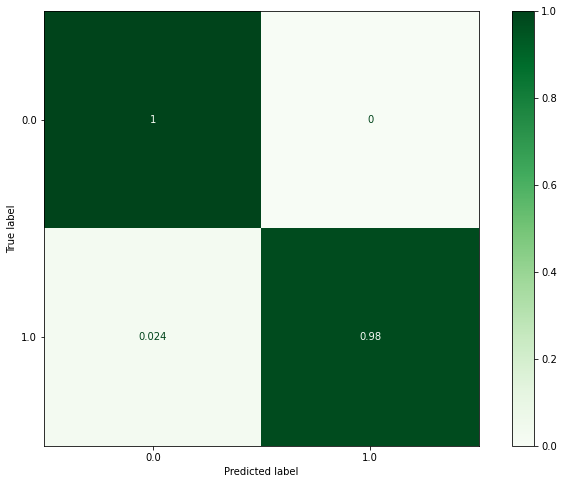

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))
plot_confusion_matrix(clf, X_test_super, y_test, normalize='true', cmap=plt.cm.Greens, ax=ax)
plt.show()